# NB-02: ペース係数・クラス別par_time推定

**目的**: NB-01の出力（adjusted_time_sec）をベースに以下の2つを推定する：
1. **Δpace係数（coeff_pace）**: ペース偏差から走破タイムへの係数（venue×surface×distance単位）
2. **par_time_class**: クラス別2着馬基準タイム（venue×surface×distance×class_rank単位）

## 入力
| ファイル | 説明 |
|---|---|
| `output/nb01/megu_dataset.parquet` | NB-01出力・全クリーニング済みデータ |
| `output/nb01/par_splits.parquet` | 基準前半スプリット（distance×surface 連続モデル） |

## 出力
| ファイル | 説明 |
|---|---|
| `output/nb02/coeff_pace.parquet` | venue×surface×distance単位ペース係数 |
| `output/nb02/par_time_class.parquet` | venue×surface×distance×class_rank単位par_time |
| `output/nb02/pace_coeff_explorer.html` | Δpace 推定のインタラクティブ可視化（会場・コース・距離選択） |
**小サンプル対策（Ridge + 縮約）**:
- coeff 欠損セルは `surface×distance_band` プールで補完（`pool_*_imputed`）
- par_time は `n_fit<10` でプールのみ（cell_shrink 禁止）

- `fit_coeff_pace`: レース平均の Ridge 傾きを `surface×distance_band` → `surface` → 理論値へ縮約（`n/(n+30)`）
- `fit_par_time_class`: 2着馬全行の Ridge（class_rank→タイム）をプールβへ縮約。beta≥0・単調性NGは prior のみ





## 1. セットアップ

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '/home/jovyan/work/keiba-vpn')
sys.path.insert(0, '/home/jovyan/work/keiba-vpn/notebooks/megu_index')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path

# 日本語フォント設定（NB-01と同様）
plt.rcParams['axes.unicode_minus'] = False
_JP_FONT_CANDIDATES = [
    '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
    '/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc',
]
_jp_font_path = next((p for p in _JP_FONT_CANDIDATES if Path(p).exists()), None)
if _jp_font_path:
    fm.fontManager.addfont(_jp_font_path)
    _jp_font_name = fm.FontProperties(fname=_jp_font_path).get_name()
    plt.rcParams['font.family'] = _jp_font_name
    plt.rcParams['font.sans-serif'] = [_jp_font_name, 'DejaVu Sans']
    print(f'日本語フォント: {_jp_font_name}')
else:
    print('WARNING: 日本語フォント未検出。`sudo apt-get install -y fonts-noto-cjk` を実行してください。')

INPUT_DIR  = Path('/home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb01')
OUTPUT_DIR = Path('/home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb02')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Setup OK')

日本語フォント: Noto Sans CJK JP
Setup OK


## 2. データロード

In [2]:
# ── megu_dataset / par_splits ロード ─────────────────────────────────────
print('megu_dataset.parquet をロード中...')
df = pd.read_parquet(INPUT_DIR / 'megu_dataset.parquet')
print(f'  megu_dataset: {df.shape}  期間: {df["date"].min()} 〜 {df["date"].max()}')

print('par_splits.parquet をロード中...')
par_splits = pd.read_parquet(INPUT_DIR / 'par_splits.parquet')
print(f'  par_splits:   {par_splits.shape}')
print(f'  par_splits 列: {par_splits.columns.tolist()}')

df['distance'] = pd.to_numeric(df['distance'], errors='coerce').astype('Int64')
par_splits['distance'] = pd.to_numeric(par_splits['distance'], errors='coerce').astype('Int64')

# ── front_split_dev（NB-01 付与済み par_front_split_sec を優先）────────────
if 'par_front_split_sec' in df.columns and df['par_front_split_sec'].notna().any():
    df['par_front_split_final'] = df['par_front_split_sec']
elif {'par_intercept', 'par_slope', 't2nd_ref'}.issubset(par_splits.columns):
    if 'race_t2nd_sec' not in df.columns:
        raise KeyError('race_t2nd_sec がありません。NB-01 を先に実行してください。')
    df = df.merge(
        par_splits[['distance', 'surface', 'par_intercept', 'par_slope', 't2nd_ref']],
        on=['distance', 'surface'], how='left',
    )
    df['par_front_split_final'] = (
        df['par_intercept'] + df['par_slope'] * (df['race_t2nd_sec'] - df['t2nd_ref'])
    )
elif 'par_front_split_final' in par_splits.columns:
    merge_keys = [c for c in ['distance', 'surface', 'track_cat'] if c in par_splits.columns]
    df = df.merge(par_splits[merge_keys + ['par_front_split_final']], on=merge_keys, how='left')
else:
    df['par_front_split_final'] = np.nan

df['front_split_dev'] = (df['front_split_sec'] - df['par_front_split_final']).fillna(0.0)

print(f'\nfront_split_dev 統計:')
print(df['front_split_dev'].describe())

df_train = df[df['year'] <= 2024].copy()
print(f'\n学習データ（year<=2024）: {len(df_train):,} 行')



megu_dataset.parquet をロード中...


  megu_dataset: (302357, 39)  期間: 2020-01-05 〜 2026-07-05
par_splits.parquet をロード中...
  par_splits:   (29, 7)
  par_splits 列: ['distance', 'surface', 'par_intercept', 'par_slope', 't2nd_ref', 'n_fit', 'model']

front_split_dev 統計:
count   302357.0000
mean        -0.0417
std          0.8307
min         -6.3517
25%         -0.5157
50%         -0.0253
75%          0.4427
max         10.9877
Name: front_split_dev, dtype: float64



学習データ（year<=2024）: 234,570 行


## 3. Δpace係数の推定（`fit_coeff_pace`）

推定セル実行後、直下にインタラクティブ HTML を表示します。


coeff_pace サマリー:
(126, 6)
source
theory                   30
cell_shrink              27
pool_distband_imputed    24
pool_surface             22
pool_distband            18
pool_shrink               5
Name: count, dtype: int64
count   126.0000
mean      0.7118
std       0.2201
min       0.3000
25%       0.7002
50%       0.7088
75%       0.8000
max       1.0433
Name: coeff_pace, dtype: float64


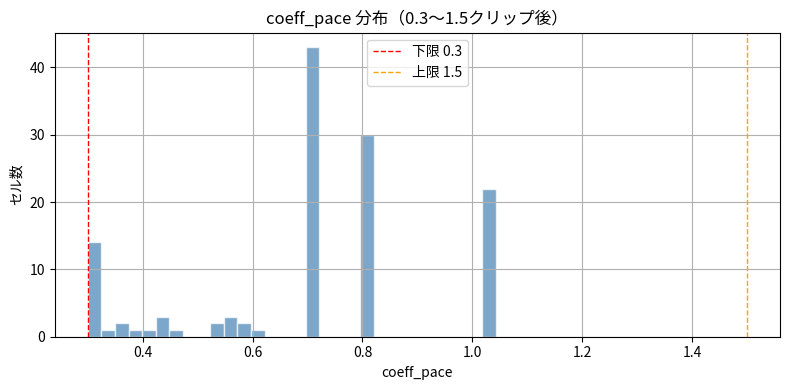

coeff_pace ヒストグラム保存完了


表示: /home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb02/pace_coeff_explorer.html
  相対パス: output/nb02/pace_coeff_explorer.html
  プレビュー URL: http://127.0.0.1:18765/output/nb02/pace_coeff_explorer.html


In [3]:
from src.pipeline.megu_index.fit_coeff_pace import fit_coeff_pace

# ── Δpace 係数（Ridge + 経験的ベイズ縮約）────────────────────────────────
coeff_pace = fit_coeff_pace(df_train)

print('coeff_pace サマリー:')
print(coeff_pace.shape)
print(coeff_pace['source'].value_counts())
print(coeff_pace['coeff_pace'].describe())

fig, ax = plt.subplots(figsize=(8, 4))
coeff_pace['coeff_pace'].hist(bins=30, ax=ax, color='steelblue', alpha=0.7, edgecolor='white')
ax.set_title('coeff_pace 分布（0.3〜1.5クリップ後）')
ax.set_xlabel('coeff_pace')
ax.set_ylabel('セル数')
ax.axvline(0.3, color='red', linestyle='--', linewidth=1, label='下限 0.3')
ax.axvline(1.5, color='orange', linestyle='--', linewidth=1, label='上限 1.5')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'coeff_pace_dist.png', dpi=80)
plt.show()
print('coeff_pace ヒストグラム保存完了')

# ── インタラクティブ可視化（このセル直下に表示）────────────────────────────
from nb_viz import load_build_script, display_interactive_html

_pace_mod = load_build_script('build_pace_viz_html')
_pace_html = _pace_mod.build_pace_viz_html(
    out_path=OUTPUT_DIR / 'pace_coeff_explorer.html',
    df_train=df_train,
    coeff_df=coeff_pace[['venue', 'surface', 'distance', 'coeff_pace', 'n_fit', 'source']],
)
display_interactive_html(_pace_html, height=720, title='Δpace エクスプローラ（会場・コース・距離を選択）')


## 4. クラスランクの付与

### 4-1. クラスランク付与（`track_speed.assign_class_rank`）


In [4]:
from src.pipeline.megu_index.track_speed import assign_class_rank

df['class_rank'] = df.apply(
    lambda r: assign_class_rank(r['grade'], r['race_class']), axis=1
)

print('class_rank 分布:')
print(df['class_rank'].value_counts(dropna=False).sort_index().to_dict())
print(f'class_rank カバレッジ: {df["class_rank"].notna().mean():.1%}')

class_rank 分布:
{1.0: 112181, 2.0: 77454, 3.0: 40766, 4.0: 19909, 5.0: 14747, 6.0: 6469, 7.0: 3448, 8.0: 2594, nan: 24789}
class_rank カバレッジ: 91.8%


### 4-3. 世代戦の除外フィルタ

In [5]:
# ── 世代戦除外フィルタ（3歳以上 or 4歳以上の混合条件戦のみ） ───────────────────
# 2歳のみ・3歳のみを除外
exclude_mask = (
    df['race_class'].str.contains('２歳|2歳', na=False) |
    (
        df['race_class'].str.contains('３歳|3歳', na=False) &
        ~df['race_class'].str.contains('以上', na=False)
    )
)
df_open = df[~exclude_mask].copy()

print(f'全データ:       {len(df):,} 行')
print(f'世代戦除外:     {exclude_mask.sum():,} 行 ({exclude_mask.mean():.1%})')
print(f'df_open（混合）: {len(df_open):,} 行')
print(f'\ndf_open class_rank 分布:')
print(df_open['class_rank'].value_counts(dropna=False).sort_index().to_dict())

全データ:       302,357 行
世代戦除外:     140,884 行 (46.6%)
df_open（混合）: 161,473 行

df_open class_rank 分布:
{1.0: 12569, 2.0: 67302, 3.0: 40084, 4.0: 19869, 5.0: 12126, 6.0: 4726, 7.0: 2265, 8.0: 1556, nan: 976}


## 5. par_time線形回帰

### 5-1. 使用データの準備

In [6]:
# ── 2着馬のみ、class_rank 1〜7、year<=2024 ──────────────────────────────
df_par_base = df_open[
    (df_open['finish_pos'] == 2) &
    (df_open['class_rank'].between(1, 7)) &
    (df_open['year'] <= 2024) &
    df_open['adjusted_time_sec'].notna()
].copy()

print(f'par_time 学習データ（2着馬、year<=2024）: {len(df_par_base):,} 行')
print(f'class_rank 分布:')
print(df_par_base['class_rank'].value_counts().sort_index().to_dict())
print(f'\nユニーク venue×surface×distance セル数: '
      f'{df_par_base.groupby(["venue","surface","distance"]).ngroups}')

par_time 学習データ（2着馬、year<=2024）: 8,610 行
class_rank 分布:
{1.0: 330, 2.0: 3850, 3.0: 2367, 4.0: 1069, 5.0: 654, 6.0: 225, 7.0: 115}

ユニーク venue×surface×distance セル数: 123


In [7]:
from src.pipeline.megu_index.fit_par_time_class import fit_par_time_class, fit_pool_betas

global_beta, pool_distband_beta = fit_pool_betas(df_par_base)
print(f'グローバルβ（Ridge）: {global_beta:.4f}')
print('プーリングβ（surface×distance_band）:')
for k, v in sorted(pool_distband_beta.items()):
    print(f'  {k}: {v:.4f}')

par_time_class = fit_par_time_class(
    df_par_base,
    global_beta,
    pool_distband_beta,
)

print(f'\npar_time_class shape: {par_time_class.shape}')
print('source 分布（venue×surface×distance セル）:')
print(par_time_class.drop_duplicates(['venue', 'surface', 'distance'])['source'].value_counts())
bad = par_time_class.drop_duplicates(['venue', 'surface', 'distance'])
print(f'beta>0 セル数: {(bad["beta"] > 0).sum()}')
print(f'\nサンプル（芝 東京 2000m）:')
sample = par_time_class[
    (par_time_class['surface'] == '芝') &
    (par_time_class['venue'].str.contains('東京', na=False)) &
    (par_time_class['distance'] == 2000)
]
if len(sample):
    print(sample[['venue','surface','distance','class_rank','par_time_sec','alpha','beta','n_fit','source']].to_string(index=False))

# ── インタラクティブ可視化（par_time・セル直下に表示）──────────────────────
from nb_viz import load_build_script, display_interactive_html

_par_mod = load_build_script('build_par_time_viz_html')
_par_html = _par_mod.build_par_time_viz_html(
    df_par_base,
    par_time_class,
    out_path=OUTPUT_DIR / 'par_time_explorer.html',
)
display_interactive_html(_par_html, height=720, title='par_time エクスプローラ（会場・コース・距離を選択）')


グローバルβ（Ridge）: -0.3830
プーリングβ（surface×distance_band）:
  ('ダート', 'long'): -0.3830
  ('ダート', 'middle'): -0.9186
  ('ダート', 'mile'): -0.7213
  ('ダート', 'sprint'): -0.3830
  ('芝', 'long'): -0.3830
  ('芝', 'middle'): -0.3830
  ('芝', 'mile'): -0.3830
  ('芝', 'sprint'): -0.3830



par_time_class shape: (861, 9)
source 分布（venue×surface×distance セル）:
source
cell_shrink      83
pool_distband    35
pool_shrink       5
Name: count, dtype: int64
beta>0 セル数: 0

サンプル（芝 東京 2000m）:
venue surface  distance  class_rank  par_time_sec    alpha    beta  n_fit      source
   東京       芝      2000           1      120.7831 121.3133 -0.5302     95 cell_shrink
   東京       芝      2000           2      120.2529 121.3133 -0.5302     95 cell_shrink
   東京       芝      2000           3      119.7227 121.3133 -0.5302     95 cell_shrink
   東京       芝      2000           4      119.1925 121.3133 -0.5302     95 cell_shrink
   東京       芝      2000           5      118.6622 121.3133 -0.5302     95 cell_shrink
   東京       芝      2000           6      118.1320 121.3133 -0.5302     95 cell_shrink
   東京       芝      2000           7      117.6018 121.3133 -0.5302     95 cell_shrink


表示: /home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb02/par_time_explorer.html
  相対パス: output/nb02/par_time_explorer.html
  プレビュー URL: http://127.0.0.1:18765/output/nb02/par_time_explorer.html


### 5-4. 品質確認

beta>0（異常）のセル数: 0  （フォールバック後は 0 が期待値）

1勝クラス(rank=2) vs G1(rank=7) par_time差 分布:
count   123.0000
mean      2.3564
std       0.9552
min       1.9149
25%       1.9149
50%       1.9149
75%       2.3958
max       9.7602
Name: diff_2vs7, dtype: float64


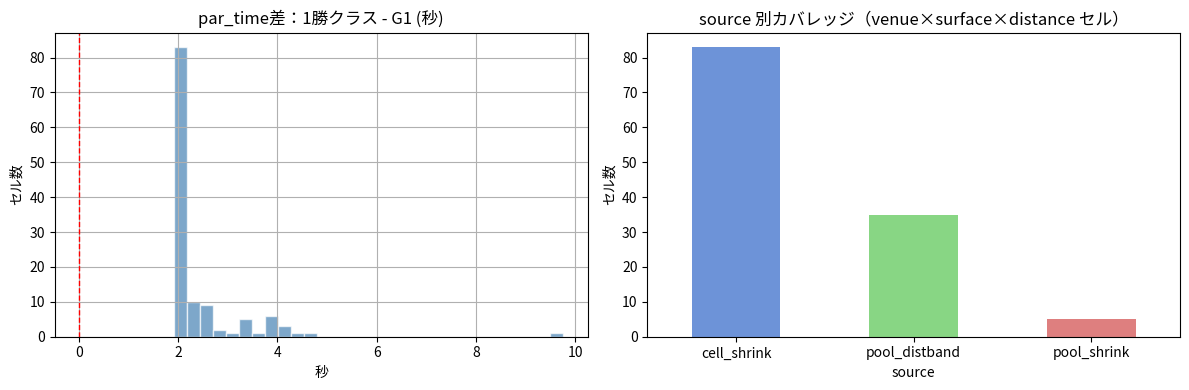

品質確認プロット保存完了


表示: /home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb02/par_time_overview.html
  相対パス: output/nb02/par_time_overview.html
  プレビュー URL: http://127.0.0.1:18765/output/nb02/par_time_overview.html


In [8]:
# ── beta>0 のセルをフラグ ─────────────────────────────────────────────────
beta_pos_mask = par_time_class['beta'] > 0
bad_cells = par_time_class[beta_pos_mask][['venue','surface','distance','beta','source']].drop_duplicates()
print(f'beta>0（異常）のセル数: {len(bad_cells):,}  （フォールバック後は 0 が期待値）')
if len(bad_cells) > 0:
    print('異常セル（先頭10件）:')
    print(bad_cells.head(10).to_string(index=False))

# ── 1勝クラス（rank=2）と G1（rank=7）の par_time 差の分布 ─────────────────
pt_rank2 = par_time_class[par_time_class['class_rank'] == 2][['venue','surface','distance','par_time_sec']].rename(columns={'par_time_sec': 'pt_rank2'})
pt_rank7 = par_time_class[par_time_class['class_rank'] == 7][['venue','surface','distance','par_time_sec']].rename(columns={'par_time_sec': 'pt_rank7'})
pt_diff = pt_rank2.merge(pt_rank7, on=['venue','surface','distance'])
pt_diff['diff_2vs7'] = pt_diff['pt_rank2'] - pt_diff['pt_rank7']

print(f'\n1勝クラス(rank=2) vs G1(rank=7) par_time差 分布:')
print(pt_diff['diff_2vs7'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pt_diff['diff_2vs7'].hist(bins=30, ax=axes[0], color='steelblue', alpha=0.7, edgecolor='white')
axes[0].set_title('par_time差：1勝クラス - G1 (秒)')
axes[0].set_xlabel('秒')
axes[0].set_ylabel('セル数')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)

# source 別カバレッジ
src_counts = par_time_class[['venue','surface','distance','source']].drop_duplicates()['source'].value_counts()
src_counts.plot.bar(ax=axes[1], color=['#4878CF','#6ACC65','#D65F5F'], alpha=0.8)
axes[1].set_title('source 別カバレッジ（venue×surface×distance セル）')
axes[1].set_xlabel('source')
axes[1].set_ylabel('セル数')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'par_time_quality.png', dpi=80)
plt.show()
print('品質確認プロット保存完了')

# ── 品質概要 HTML（セル直下に表示）────────────────────────────────────────
from nb_viz import load_build_script, display_interactive_html

_overview_html = _par_mod.build_par_time_overview_html(
    par_time_class,
    out_path=OUTPUT_DIR / 'par_time_overview.html',
)
display_interactive_html(_overview_html, height=620, title='par_time 品質概要（rank2−rank7 差・beta 分布）')


## 6. 保存

In [9]:
# ── coeff_pace.parquet ────────────────────────────────────────────────────
# スキーマ: venue, surface, distance, coeff_pace, n_fit, source
coeff_pace_out = coeff_pace[['venue', 'surface', 'distance', 'coeff_pace', 'n_fit', 'source']].copy()
path_coeff = OUTPUT_DIR / 'coeff_pace.parquet'
coeff_pace_out.to_parquet(path_coeff, index=False)
print(f'coeff_pace 保存完了: {path_coeff}')
print(f'  shape: {coeff_pace_out.shape}')
print(coeff_pace_out.head())

# ── par_time_class.parquet ────────────────────────────────────────────────
# スキーマ: venue, surface, distance, class_rank, par_time_sec, alpha, beta, n_fit, source
par_time_out = par_time_class[[
    'venue', 'surface', 'distance', 'class_rank',
    'par_time_sec', 'alpha', 'beta', 'n_fit', 'source'
]].copy()
path_par = OUTPUT_DIR / 'par_time_class.parquet'
par_time_out.to_parquet(path_par, index=False)
print(f'\npar_time_class 保存完了: {path_par}')
print(f'  shape: {par_time_out.shape}')
print(par_time_out.head())

print('\n=== NB-02 完了 ===')
print(f'  coeff_pace:     {coeff_pace_out.shape}')
print(f'  par_time_class: {par_time_out.shape}')

coeff_pace 保存完了: /home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb02/coeff_pace.parquet
  shape: (126, 6)
  venue surface  distance  coeff_pace  n_fit        source
0    中京     ダート      1200      1.0433    234  pool_surface
1    中京     ダート      1400      1.0433    318  pool_surface
2    中京     ダート      1800      1.0433    441  pool_surface
3    中京     ダート      1900      1.0433    152  pool_surface
4    中京       芝      1200      0.4248    121   cell_shrink

par_time_class 保存完了: /home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb02/par_time_class.parquet
  shape: (861, 9)
  venue surface  distance  class_rank  par_time_sec   alpha    beta  n_fit  \
0    札幌     ダート      1000           1       59.7949 60.2341 -0.4392     45   
1    札幌     ダート      1000           2       59.3556 60.2341 -0.4392     45   
2    札幌     ダート      1000           3       58.9164 60.2341 -0.4392     45   
3    札幌     ダート      1000           4       58.4772 60.2341 -0.4392     45   
4    札幌     ダート  